# **COLAB CONFIGURATION**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
%cd /content/drive/MyDrive/College/FLEX-Med/flex-med/

/content/drive/MyDrive/College/FLEX-Med/flex-med


# **DATASET SETUP**
- Set up the public dataset with 20% CNMC and 20% ALL_IDB2
- New ALLIDB and CNMC dataset

In [ ]:
import os
import shutil
import random
import glob
from pathlib import Path
from tqdm import tqdm

# <---------------- CONFIGURATION ---------------->
# Define where your uploaded data sits currently
SOURCE_ROOT = "/content/drive/MyDrive/College/Datasets"
PATH_ALLIDB = os.path.join(SOURCE_ROOT, "ALL_IDB2", "img")
PATH_CNMC_ALL = os.path.join(SOURCE_ROOT, "CNMC", "all")
PATH_CNMC_HEM = os.path.join(SOURCE_ROOT, "CNMC", "hem")

# Define where you want the new Federation-ready data to go
OUTPUT_ROOT = "/content/drive/MyDrive/College/Datasets/fed_data"
SPLIT_RATIO = 0.2  # 20% for Public Anchor

# <---------------- SETUP DIRECTORIES ---------------->
def create_dir_structure(base_path):
    for split in ["public_anchor", "client_cnmc", "client_allidb"]:
        for label in ["all", "hem"]:
            os.makedirs(os.path.join(base_path, split, label), exist_ok=True)

print(f"Creating directory structure at {OUTPUT_ROOT}...")
create_dir_structure(OUTPUT_ROOT)

# <---------------- HELPER FUNCTIONS ---------------->
def copy_files(file_list, destination_split, label, dataset_prefix):
    """
    Copies files to destination.
    Renames them with prefix to avoid collisions in the Public folder.
    """
    dest_dir = os.path.join(OUTPUT_ROOT, destination_split, label)

    for src_path in file_list:
        filename = os.path.basename(src_path)
        new_filename = f"{dataset_prefix}_{filename}"
        dst_path = os.path.join(dest_dir, new_filename)
        shutil.copy2(src_path, dst_path)

# <---------------- PROCESS ALL-IDB2 ---------------->
print("\nProcessing ALL-IDB2...")
allidb_images = glob.glob(os.path.join(PATH_ALLIDB, "*"))
allidb_all = [] # Blasts (1)
allidb_hem = [] # Healthy (0)

# Parse filenames based on: ImXXX_Y.jpg (Y=0 Healthy, Y=1 ALL)
for img_path in allidb_images:
    filename = os.path.basename(img_path)
    # Extract the digit before .jpg
    try:
        label_char = filename.split('_')[-1].split('.')[0]
        if label_char == '1':
            allidb_all.append(img_path)
        elif label_char == '0':
            allidb_hem.append(img_path)
    except Exception as e:
        print(f"Skipping malformed file: {filename}")

# Shuffle
random.shuffle(allidb_all)
random.shuffle(allidb_hem)

# Split ALL (Leukemia)
split_idx_all = int(len(allidb_all) * SPLIT_RATIO)
public_allidb_all = allidb_all[:split_idx_all]
private_allidb_all = allidb_all[split_idx_all:]

# Split HEM (Healthy)
split_idx_hem = int(len(allidb_hem) * SPLIT_RATIO)
public_allidb_hem = allidb_hem[:split_idx_hem]
private_allidb_hem = allidb_hem[split_idx_hem:]

# Execute Copy
# 1. To Public Anchor
copy_files(public_allidb_all, "public_anchor", "all", "allidb")
copy_files(public_allidb_hem, "public_anchor", "hem", "allidb")

# 2. To Client Private (Client 0)
copy_files(private_allidb_all, "client_allidb", "all", "allidb")
copy_files(private_allidb_hem, "client_allidb", "hem", "allidb")

print(f"ALL-IDB2 Done. Public: {len(public_allidb_all)+len(public_allidb_hem)}, Private: {len(private_allidb_all)+len(private_allidb_hem)}")

# <---------------- PROCESS CNMC ---------------->
print("\nProcessing CNMC...")

# Get file lists
cnmc_all = glob.glob(os.path.join(PATH_CNMC_ALL, "*"))
cnmc_hem = glob.glob(os.path.join(PATH_CNMC_HEM, "*"))

# Shuffle
random.shuffle(cnmc_all)
random.shuffle(cnmc_hem)

# Split ALL
split_idx_all = int(len(cnmc_all) * SPLIT_RATIO)
public_cnmc_all = cnmc_all[:split_idx_all]
private_cnmc_all = cnmc_all[split_idx_all:]

# Split HEM
split_idx_hem = int(len(cnmc_hem) * SPLIT_RATIO)
public_cnmc_hem = cnmc_hem[:split_idx_hem]
private_cnmc_hem = cnmc_hem[split_idx_hem:]

# Execute Copy
# 1. To Public Anchor
copy_files(public_cnmc_all, "public_anchor", "all", "cnmc")
copy_files(public_cnmc_hem, "public_anchor", "hem", "cnmc")

# 2. To Client Private (Client 1)
copy_files(private_cnmc_all, "client_cnmc", "all", "cnmc")
copy_files(private_cnmc_hem, "client_cnmc", "hem", "cnmc")

print(f"CNMC Done. Public: {len(public_cnmc_all)+len(public_cnmc_hem)}, Private: {len(private_cnmc_all)+len(private_cnmc_hem)}")

# <---------------- FINAL SUMMARY ---------------->
print("\n" + "="*30)
print("DATASET GENERATION COMPLETE")
print("="*30)
print(f"New Public Anchor Size (Total): {len(os.listdir(os.path.join(OUTPUT_ROOT, 'public_anchor', 'all'))) + len(os.listdir(os.path.join(OUTPUT_ROOT, 'public_anchor', 'hem')))}")
print(f"Client ALL-IDB2 Size (Private): {len(os.listdir(os.path.join(OUTPUT_ROOT, 'client_allidb', 'all'))) + len(os.listdir(os.path.join(OUTPUT_ROOT, 'client_allidb', 'hem')))}")
print(f"Client CNMC Size (Private):     {len(os.listdir(os.path.join(OUTPUT_ROOT, 'client_cnmc', 'all'))) + len(os.listdir(os.path.join(OUTPUT_ROOT, 'client_cnmc', 'hem')))}")
print(f"\nData is ready at: {OUTPUT_ROOT}")

# **FLOWER RUN**

In [6]:
!python -m pip install flwr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 787.9/787.9 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 120.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 105.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.4/242.4 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.1/250.1 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.0/47.0 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1
  Attempting uninstall: rich
    Found existing installation: rich 14.2.0
    Uninstalling rich-14.2.0:
      Successfully uninstalled rich-14.2.0
  Attempting uninstall: cryptography
    Found existing installation: cryptography 3.4.8
    Uninstalling cryptography-3.4.8:
      Successfully unin

In [7]:
!python -m pip install "flwr[simulation]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.4/71.4 MB 12.4 MB/s eta 0:00:00


In [8]:
!pip install -e .

Obtaining file:///content/drive/MyDrive/College/FLEX-Med/flex-med
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.1/75.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 720.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 157.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 165.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 862.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
!flwr run .

# **Inference code where we can pass the image path**

Loading model from: model_client_2.pt
✓ Successfully loaded: DenseNet121 (Client 2 - Free Rider)
Loading Test Data from: /content/drive/MyDrive/College/Datasets/fed_data/public_anchor
Found 2111 images.


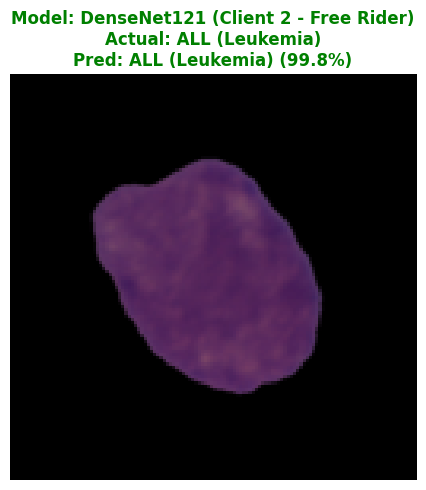

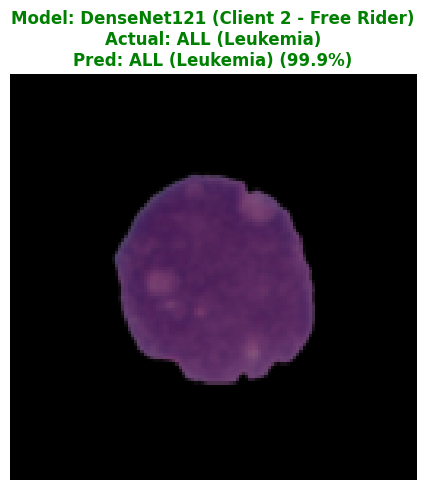

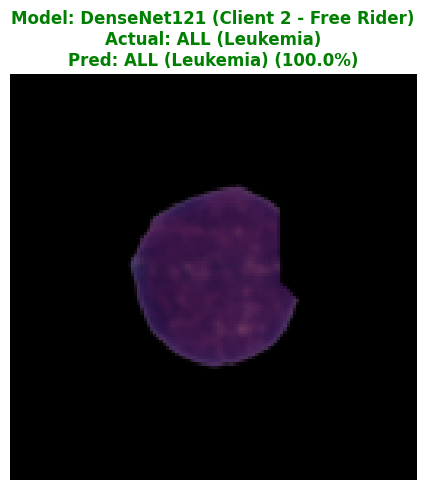

In [21]:
import sys
import os

# ==========================================
# 0. SETUP PATHS
# ==========================================
PACKAGE_ROOT = "/content/drive/MyDrive/College/FLEX-Med/flex-med/"
if PACKAGE_ROOT not in sys.path:
    sys.path.append(PACKAGE_ROOT)

import torch
import matplotlib.pyplot as plt
import numpy as np
import re
from PIL import Image
from torchvision import datasets

from flex_med.task import (
    get_resnet,
    get_mobilenet,
    get_densenet,
    COMMON_TRANSFORM,
    IMG_SIZE
)

# ==========================================
# 1. CONFIGURATION
# ==========================================

MODEL_PATH = "model_client_2.pt"   # Change for other clients
TEST_DATA_PATH = "/content/drive/MyDrive/College/Datasets/fed_data/public_anchor"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASSES = ['ALL (Leukemia)', 'Hem (Healthy)']

# ==========================================
# 2. AUTOMATIC ARCHITECTURE SELECTOR
# ==========================================
def get_model_and_name(path):
    match = re.search(r'model_client_(\d+).pt', path)

    if not match:
        print("Could not deduce Client ID from filename. Defaulting to ResNet.")
        return get_resnet(), "ResNet18 (Default)"

    client_id = int(match.group(1))
    mod = client_id % 3

    if mod == 0:
       return get_resnet(), f"ResNet18 (Client {client_id} - ALL-IDB2)"
    elif mod == 1:
       return get_mobilenet(), f"MobileNetV2 (Client {client_id} - CNMC)"
    else:
       return get_densenet(), f"DenseNet121 (Client {client_id} - Free Rider)"

# ==========================================
# 3. LOAD MODEL
# ==========================================
if not os.path.exists(MODEL_PATH):
    print(f"ERROR: Model file not found at: {MODEL_PATH}")
    exit()

print(f"Loading model from: {MODEL_PATH}")
model, model_name = get_model_and_name(MODEL_PATH)
model.to(DEVICE)

try:
    state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
    model.load_state_dict(state_dict)
    model.eval()
    print(f"✓ Successfully loaded: {model_name}")
except Exception as e:
    print(f"Error loading weights: {e}")
    exit()

# ==========================================
# 4. LOAD TEST DATA (Optional for random)
# ==========================================
print(f"Loading Test Data from: {TEST_DATA_PATH}")
if not os.path.exists(TEST_DATA_PATH):
    print(f"Error: Data path {TEST_DATA_PATH} does not exist.")
    exit()

ds_test = datasets.ImageFolder(root=TEST_DATA_PATH, transform=COMMON_TRANSFORM)
print(f"Found {len(ds_test)} images.")

# ==========================================
# 5. VISUALIZATION HELPER
# ==========================================
def unnormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

# ==========================================
# 6. RANDOM PREDICTION FUNCTION
# ==========================================
def predict_random_image():
    index = np.random.randint(len(ds_test))
    image_tensor, true_label_idx = ds_test[index]
    true_label_name = CLASSES[true_label_idx]

    input_batch = image_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(input_batch)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        predicted_idx = outputs.argmax(dim=1).item()
        confidence = probabilities[0][predicted_idx].item()

    predicted_name = CLASSES[predicted_idx]
    color = 'green' if predicted_idx == true_label_idx else 'red'

    disp_img = unnormalize(image_tensor.cpu()).permute(1, 2, 0).numpy()
    disp_img = np.clip(disp_img, 0, 1)

    title_text = (
        f"Model: {model_name}\n"
        f"Actual: {true_label_name}\n"
        f"Pred: {predicted_name} ({confidence:.1%})"
    )

    plt.figure(figsize=(5, 5))
    plt.imshow(disp_img)
    plt.title(title_text, color=color, fontweight='bold', fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# ==========================================
# 7. MANUAL IMAGE PREDICTION FUNCTION
# ==========================================
def predict_image_from_path(img_path):
    if not os.path.exists(img_path):
        print(f"Error: Image path not found: {img_path}")
        return

    # Load and transform
    img = Image.open(img_path).convert("RGB")
    img_tensor = COMMON_TRANSFORM(img)
    input_batch = img_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(input_batch)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        predicted_idx = outputs.argmax(dim=1).item()
        confidence = probabilities[0][predicted_idx].item()

    predicted_name = CLASSES[predicted_idx]

    disp_img = unnormalize(img_tensor.cpu()).permute(1, 2, 0).numpy()
    disp_img = np.clip(disp_img, 0, 1)

    title_text = (
        f"Model: {model_name}\n"
        f"Predicted: {predicted_name}\n"
        f"Confidence: {confidence:.1%}"
    )

    plt.figure(figsize=(5, 5))
    plt.imshow(disp_img)
    plt.title(title_text, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# ==========================================
# 8. RUN
# ==========================================

# Example 1: Random predictions from dataset
for i in range(3):
    predict_random_image()

# Example 2: Manual image path prediction
# predict_image_from_path("/content/drive/MyDrive/College/Datasets/fed_data/public_anchor/hem/allidb_Im132_0.tif")

# **SSH SETUP**

In [15]:
# Run Once
!mkdir -p /content/drive/MyDrive/colab_ssh_keys

In [16]:
# Run Once
!ssh-keygen -t ed25519 -C "s.shrenikdeep@gmail.com" -f /content/drive/MyDrive/colab_ssh_keys/colab_key -N ""

Generating public/private ed25519 key pair.
Your identification has been saved in /content/drive/MyDrive/colab_ssh_keys/colab_key
Your public key has been saved in /content/drive/MyDrive/colab_ssh_keys/colab_key.pub
The key fingerprint is:
SHA256:ffV8lP73yUIY24qx3KtmShD18R7atyh0wY/fmG+XrP4 s.shrenikdeep@gmail.com
The key's randomart image is:
+--[ED25519 256]--+
|       . .       |
|      . . +     .|
|     .   . =  ...|
|      .  .+.=..+ |
|     .  So.=*o .+|
|      . ...++o= o|
|       ...=.o=..+|
|      .  *.o .o+=|
|       .+...oo=Eo|
+----[SHA256]-----+


In [17]:
# Run Once
!cat /content/drive/MyDrive/colab_ssh_keys/colab_key.pub

ssh-ed25519 AAAAC3NzaC1lZDI1NTE5AAAAIOj8H7Axo8HqpWKpdU9ZLXH5zcoreXgp/CrZygcbq3Qy s.shrenikdeep@gmail.com


In [26]:
# Run Once
!git config --global user.name "Shrenik Deep"
!git config --global user.email "s.shrenikdeep@gmail.com"

In [18]:
!mkdir -p ~/.ssh

# Copy key from Drive to the VM
!cp /content/drive/MyDrive/colab_ssh_keys/colab_key ~/.ssh/id_ed25519
!cp /content/drive/MyDrive/colab_ssh_keys/colab_key.pub ~/.ssh/id_ed25519.pub

# Secure permissions
!chmod 600 ~/.ssh/id_ed25519

# Add GitHub to known hosts
!ssh-keyscan -H github.com >> ~/.ssh/known_hosts

# github.com:22 SSH-2.0-23ccf21
# github.com:22 SSH-2.0-23ccf21
# github.com:22 SSH-2.0-23ccf21
# github.com:22 SSH-2.0-23ccf21
# github.com:22 SSH-2.0-23ccf21


In [19]:
!ssh -T git@github.com

Hi Shrenik0321! You've successfully authenticated, but GitHub does not provide shell access.


In [23]:
# !git clone git@github.com:Shrenik0321/FLEX-Med.git
!git add .

In [27]:
!git add .
!git commit -m "updates from colab"
!git push

[main cd3ea51] updates
 9 files changed, 250 insertions(+), 260 deletions(-)
 create mode 100644 flex-med/final_consensus.npy
 create mode 100644 flex-med/model_client_0.pt
 create mode 100644 flex-med/model_client_1.pt
 create mode 100644 flex-med/model_client_2.pt
 rewrite main.ipynb (100%)


In [32]:
!git push

Everything up-to-date


# **GITHUB SETUP**

In [11]:
!git pull

Host key verification failed.
fatal: Could not read from remote repository.

Please make sure you have the correct access rights
and the repository exists.
